In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from apriori_miner import AprioriMiner

In [7]:
def clean_disease_data(df):
    """
    Basic cleaning: whitespace, empty strings, basic formatting.
    """  
    df = df.copy()
    # Remove whitespace
    string_cols = df.select_dtypes(include="object").columns
    for col in string_cols:
        df[col] = df[col].str.strip() if df[col].dtype == "object" else df[col]

    # Replace empty strings with NaN
    df = df.replace("", np.nan)

    # Lowercase and replace spaces with underscores
    symptom_cols = [col for col in df.columns if "Symptom" in col]
    for col in symptom_cols:
        df[col] = (
            df[col].str.lower().str.replace(" _", "_").str.replace("_ ", "_")
        )

    return df


def normalize_symptoms(df, normalization_dict):
    """
    Normalize symptoms using a mapping dictionary.
    """
    df = df.copy()

    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for col in symptom_cols:
        df[col] = df[col].map(
            lambda x: normalization_dict.get(x, x) if pd.notna(x) else x
        )

    return df


def preprocess_disease_data(df, norm_dict):
    """Clean -> normalize (NO merging)"""
    df = clean_disease_data(df)
    df = normalize_symptoms(df, norm_dict)
    return df


def convert_to_transactions(df, keep_disease_label=False):
    """
    Convert disease-symptom dataframe to transaction format for Apriori.

    Each ROW becomes a transaction containing its symptoms.

    Parameters:
    - df: DataFrame with Disease and Symptom columns
    - keep_disease_label: If True, return (disease, symptoms) tuples

    Returns:
    - If keep_disease_label=False: list of frozensets
    - If keep_disease_label=True: list of (disease, frozenset) tuples
    """
    transactions = []
    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for _, row in df.iterrows():
        disease = row["Disease"]
        # Collect non-null symptoms for this row
        symptoms = [row[col] for col in symptom_cols if pd.notna(row[col])]

        # Only add if there are symptoms
        if symptoms:
            if keep_disease_label:
                transactions.append((disease, frozenset(symptoms)))
            else:
                transactions.append(frozenset(symptoms))

    return transactions


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

# Load raw data
df_raw = pd.read_csv("raw/itachi9604_disease-symptom-description-dataset.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Unique diseases: {df_raw['Disease'].nunique()}")
print(f"Total patient instances: {len(df_raw)}")
display(df_raw.head())

# Preprocess (clean + normalize) - NO MERGING
normalization_dict = {
    # Add your normalization mappings here
    # "symptom_variation1": "standard_symptom",
    # "symptom_variation2": "standard_symptom",
}

df_processed = preprocess_disease_data(df_raw, normalization_dict)

# Convert to transactions (each row = one patient instance)
transactions = convert_to_transactions(df_processed, keep_disease_label=False)
transactions_with_labels = convert_to_transactions(
    df_processed, keep_disease_label=True
)

print(f"\nTotal transactions: {len(transactions)}")
print(f"Example transaction: {list(transactions[0])[:5]}...")

# Show disease distribution
disease_counts = df_processed["Disease"].value_counts()
print("\nTop 10 diseases by instance count:")
print(disease_counts.head(10))


Raw data shape: (4920, 18)
Unique diseases: 41
Total patient instances: 4920


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Total transactions: 4920
Example transaction: ['itching', 'nodal_skin_eruptions', 'skin_rash', 'dischromic_patches']...

Top 10 diseases by instance count:
Disease
Fungal infection                120
Hepatitis C                     120
Hepatitis E                     120
Alcoholic hepatitis             120
Tuberculosis                    120
Common Cold                     120
Pneumonia                       120
Dimorphic hemmorhoids(piles)    120
Heart attack                    120
Varicose veins                  120
Name: count, dtype: int64


In [8]:
results = []

for disease in df_processed["Disease"].unique():
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)
    
    if len(disease_transactions) < 3:
        continue
    
    miner = AprioriMiner(min_support=0.5)
    miner.fit(disease_transactions)
    
    if not miner.all_frequent_itemsets:
        continue

    # ---- LONGEST FREQUENT ITEMSET ----
    max_k = max(len(items) for items, _ in miner.all_frequent_itemsets)

    longest_items, support_count = max(
        ((items, count) for items, count in miner.all_frequent_itemsets
         if len(items) == max_k),
        key=lambda x: x[1]
    )

    support = support_count / len(disease_transactions)
    longest_itemset_str = ", ".join(sorted(longest_items))

    # ---- NEW: average number of symptoms ----
    avg_symptom_count = float(np.mean([len(t) for t in disease_transactions]))

    # ---- SAVE RESULTS ----
    results.append({
        "disease": disease,
        "longest_itemset_string": longest_itemset_str,
        "length_of_longest_itemset": max_k,
        "support": support,
        "support_count": support_count,
        "avg_symptoms": avg_symptom_count
    })

results_df = pd.DataFrame(results)
results_df


Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 4 frequent 1-itemsets
Generating 2-itemsets...
  Found 0 frequent 2-itemsets
Total frequent itemsets: 4
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 4 frequent 1-itemsets
Generating 2-itemsets...
  Found 0 frequent 2-itemsets
Total frequent itemsets: 4
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 6 frequent 1-itemsets
Generating 2-itemsets...
  Found 3 frequent 2-itemsets
Generating 3-itemsets...
  Found 0 frequent 3-itemsets
Total frequent itemsets: 9
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 7 frequent 1-itemsets
Generating 2-itemsets...
  Found 21 frequent 2-itemsets
Generating 3-itemsets...
  Found 0 frequent 3-itemsets
Total frequent itemsets: 28
Fitting Apriori with min_support=0.9 (count=108)

,disease,longest_itemset_string,length_of_longest_itemset,support,support_count,avg_symptoms
0,Fungal infection,itching,1,0.90,108,3.60
1,Allergy,watering_from_eyes,1,0.90,108,3.60
2,GERD,"chest_pain, stomach_pain",2,0.90,108,5.55
3,Chronic cholestasis,"vomiting, yellowing_of_eyes",2,0.90,108,6.65
4,Drug Reaction,itching,1,0.95,114,4.55
5,Peptic ulcer diseae,"abdominal_pain, passage_of_gases",2,0.90,108,5.60
6,AIDS,high_fever,1,0.95,114,3.65
7,Diabetes,"increased_appetite, irregular_sugar_level, pol...",4,0.90,108,9.60
8,Gastroenteritis,diarrhoea,1,0.95,114,3.65
9,Bronchial Asthma,"breathlessness, mucoid_sputum",2,0.90,108,5.60


### The following diseases have discriminative symptoms with 0.9 support, making them easily diagnosable


In [9]:
from collections import defaultdict

itemset_to_diseases = defaultdict(set)

for _, row in results_df.iterrows():
    items = frozenset(row["longest_itemset_string"].split(", "))
    itemset_to_diseases[items].add(row["disease"])

discriminative_rows = []

for items, diseases in itemset_to_diseases.items():
    if len(diseases) == 1:
        disease = list(diseases)[0]
        row = results_df[results_df["disease"] == disease].iloc[0]
        discriminative_rows.append(row)

discriminative_df = pd.DataFrame(discriminative_rows)
discriminative_df



,disease,longest_itemset_string,length_of_longest_itemset,support,support_count,avg_symptoms
1,Allergy,watering_from_eyes,1,0.90,108,3.60
2,GERD,"chest_pain, stomach_pain",2,0.90,108,5.55
3,Chronic cholestasis,"vomiting, yellowing_of_eyes",2,0.90,108,6.65
5,Peptic ulcer diseae,"abdominal_pain, passage_of_gases",2,0.90,108,5.60
6,AIDS,high_fever,1,0.95,114,3.65
7,Diabetes,"increased_appetite, irregular_sugar_level, pol...",4,0.90,108,9.60
8,Gastroenteritis,diarrhoea,1,0.95,114,3.65
9,Bronchial Asthma,"breathlessness, mucoid_sputum",2,0.90,108,5.60
10,Hypertension,"lack_of_concentration, loss_of_balance",2,0.90,108,4.60
11,Migraine,"depression, irritability",2,0.90,108,8.55


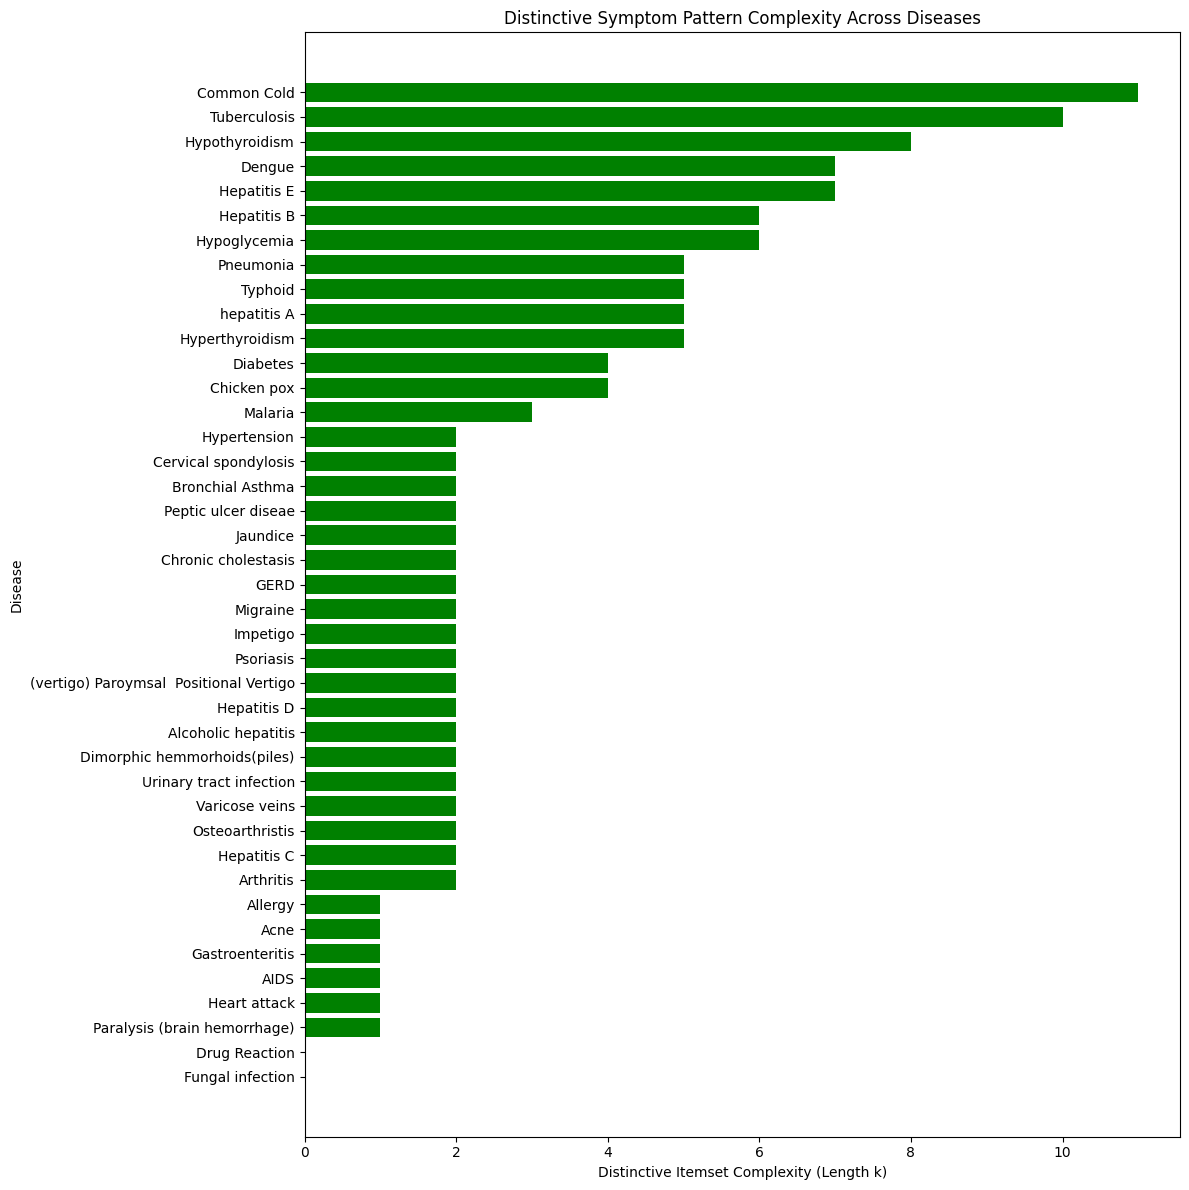

In [10]:
# Complexity = k if discriminative else 0
results_df["distinctive_complexity"] = np.where(
    results_df["disease"].isin(discriminative_df["disease"]),
    results_df["length_of_longest_itemset"],
    0
)

# Sort by complexity
plot_df = results_df.sort_values("distinctive_complexity", ascending=True)

plt.figure(figsize=(12, 12))
plt.barh(
    plot_df["disease"],
    plot_df["distinctive_complexity"],
    color=["green" if c > 0 else "lightgray" for c in plot_df["distinctive_complexity"]]
)

plt.xlabel("Distinctive Itemset Complexity (Length k)")
plt.ylabel("Disease")
plt.title("Distinctive Symptom Pattern Complexity Across Diseases")

plt.tight_layout()
plt.show()


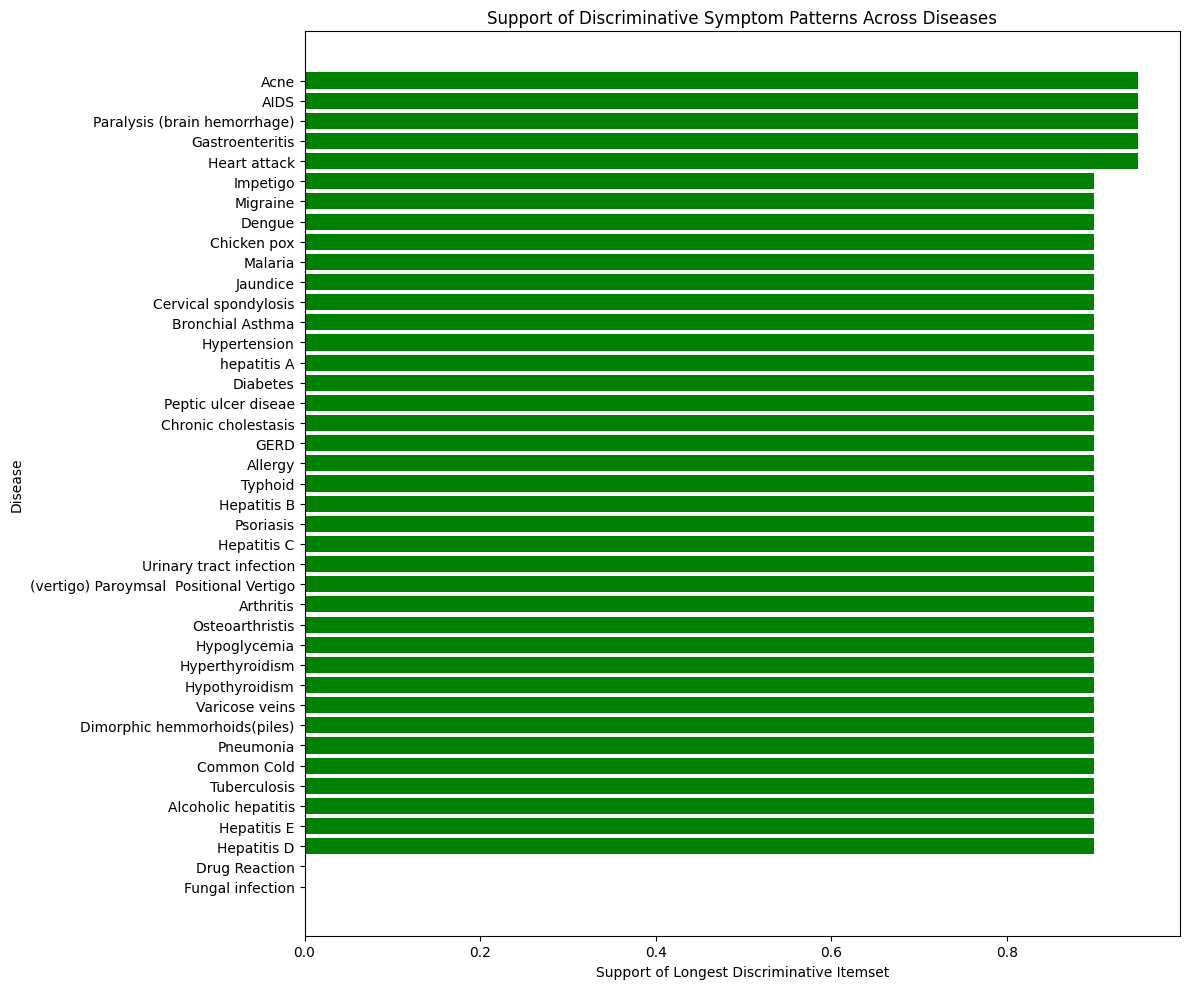

In [11]:
results_df["discriminative_support"] = np.where(
    results_df["disease"].isin(discriminative_df["disease"]),
    results_df["support"],
    0  # non-discriminative diseases get 0
)

# Sort by support for clean plotting
plot_df = results_df.sort_values("discriminative_support", ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(
    plot_df["disease"],
    plot_df["discriminative_support"],
    color=["green" if s > 0 else "lightgray" for s in plot_df["discriminative_support"]]
)

plt.xlabel("Support of Longest Discriminative Itemset")
plt.ylabel("Disease")
plt.title("Support of Discriminative Symptom Patterns Across Diseases")

plt.tight_layout()
plt.show()


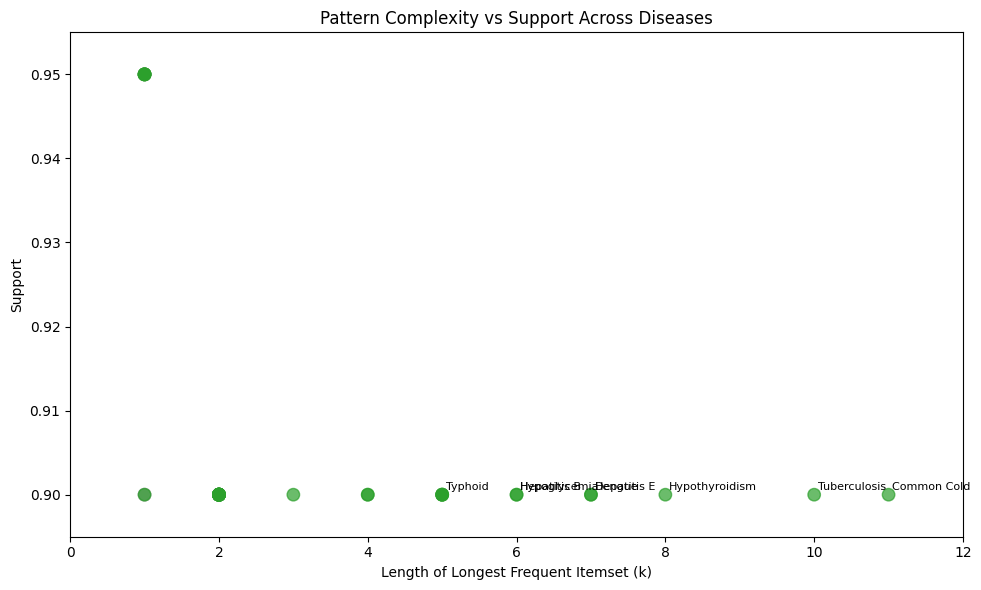

In [20]:
# Use the existing results_df and discriminative_df
results_df["is_discriminative"] = results_df["disease"].isin(discriminative_df["disease"])

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter: all diseases, colored by discriminative or not
ax.scatter(
    results_df["length_of_longest_itemset"],
    results_df["support"],
    s=80,
    alpha=0.7,
    c=np.where(results_df["is_discriminative"], "tab:green", "tab:gray"),
)

ax.set_xlabel("Length of Longest Frequent Itemset (k)")
ax.set_ylabel("Support")
ax.set_title("Pattern Complexity vs Support Across Diseases")

# --- Only annotate the most informative diseases ---
# e.g. top 8 by (k, support)
to_annotate = results_df.sort_values(
    ["length_of_longest_itemset", "support"],
    ascending=False
).head(8)

for _, row in to_annotate.iterrows():
    ax.text(
        row["length_of_longest_itemset"] + 0.05,
        row["support"] + 0.0005,
        row["disease"],
        fontsize=8,
    )

# Slight padding so labels are visible
ax.margins(x=0.1, y=0.1)

plt.tight_layout()
plt.show()


/var/folders/l4/2j1s87ls64b0s5_8t7zx38lm0000gn/T/ipykernel_27092/4098688453.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_df.loc[disease] = heatmap_df.loc[disease] / n_tx
/var/folders/l4/2j1s87ls64b0s5_8t7zx38lm0000gn/T/ipykernel_27092/4098688453.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_df.loc[disease] = heatmap_df.loc[disease] / n_tx
/var/folders/l4/2j1s87ls64b0s5_8t7zx38lm0000gn/T/ipykernel_27092/4098688453.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9' has dtype incompatible with int64, please explicitly cast

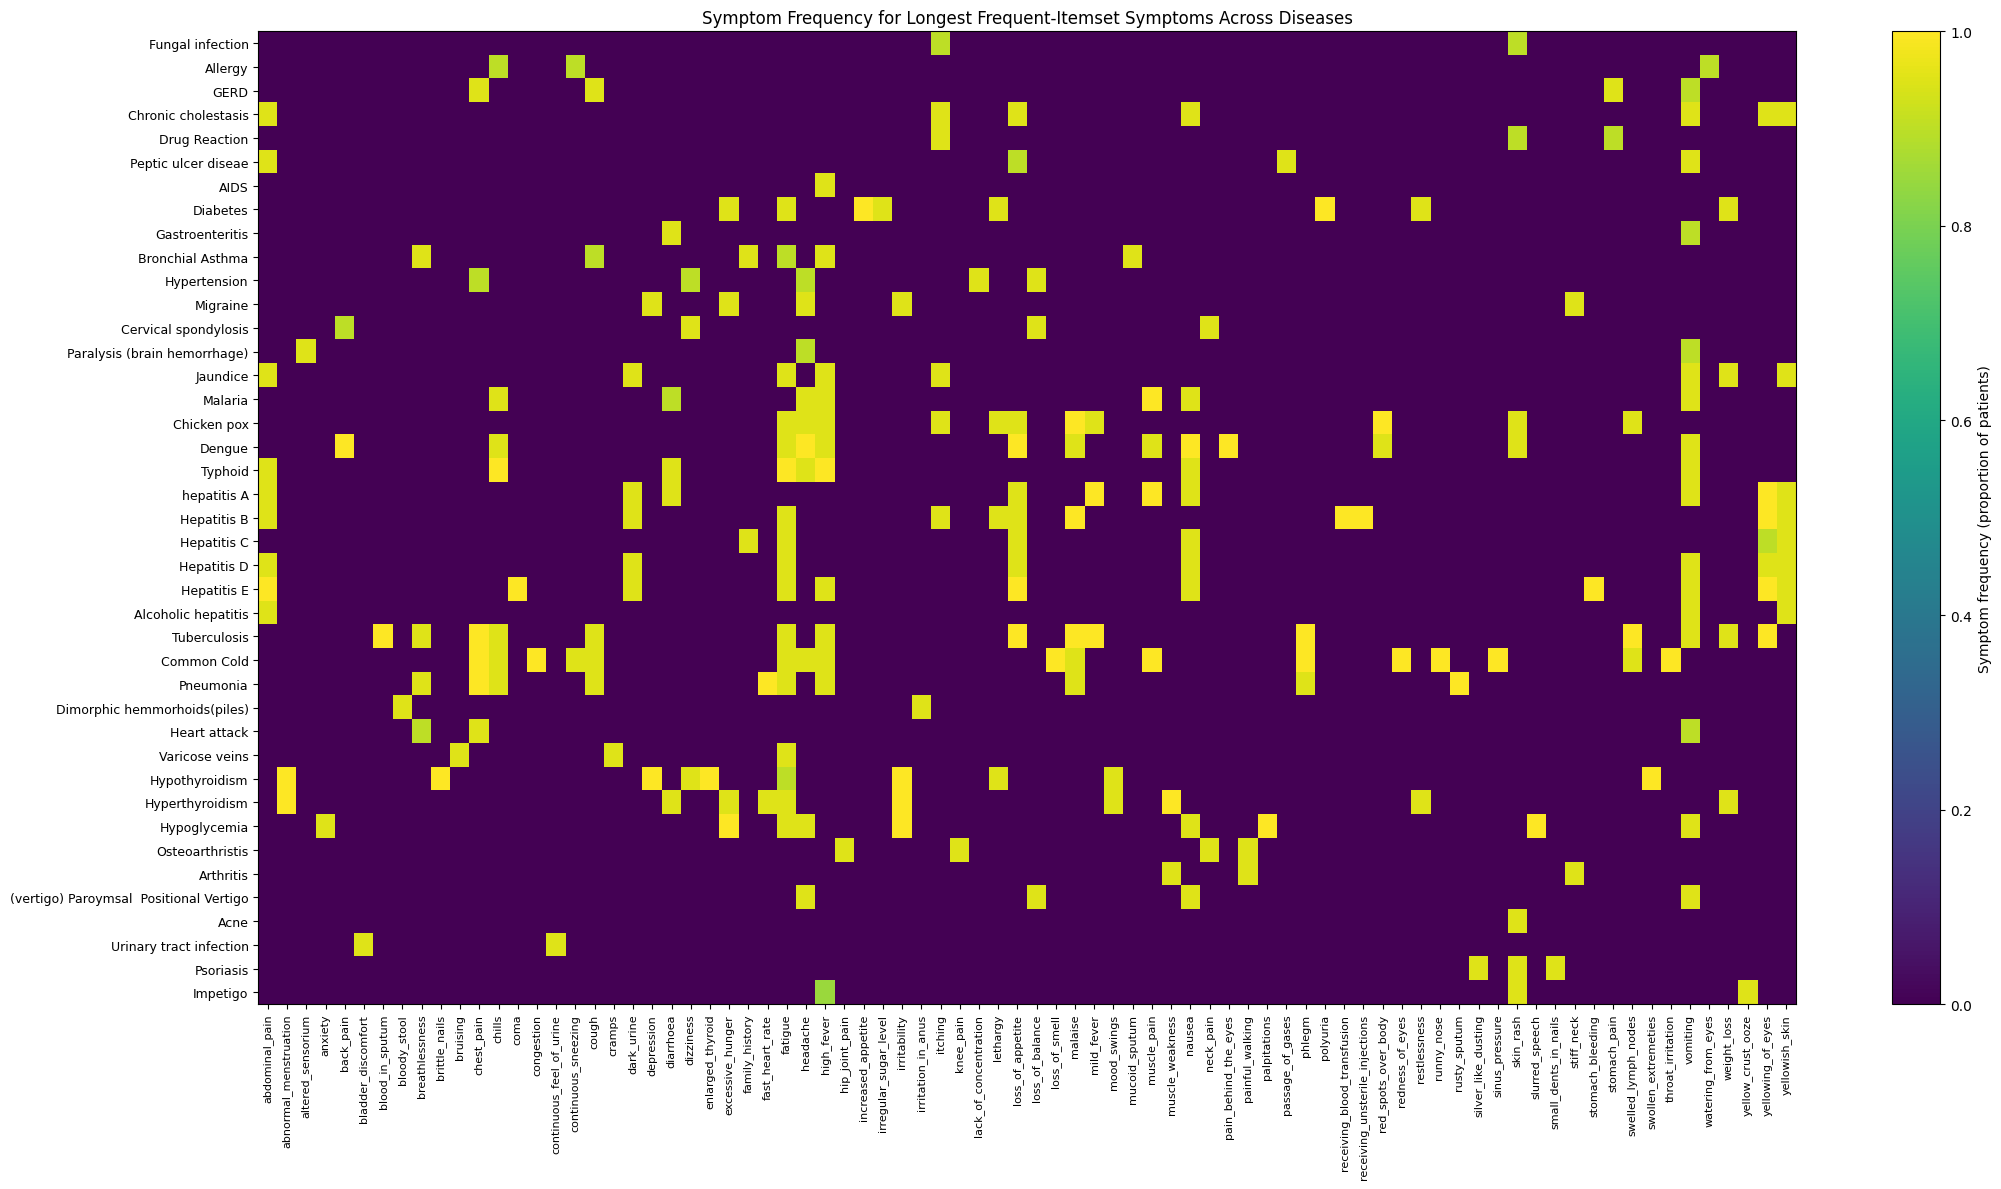

In [18]:
# Get union of all symptoms that appear in the longest itemset of at least one disease
relevant_symptoms = sorted(
    set().union(*[
        set(s.split(", "))
        for s in results_df["longest_itemset_string"]
    ])
)

# Create empty matrix: diseases x relevant symptoms
heatmap_df = pd.DataFrame(
    0,
    index=results_df["disease"],
    columns=relevant_symptoms
)
for disease in results_df["disease"]:
    disease_df = df_processed[df_processed["Disease"] == disease]
    transactions = convert_to_transactions(disease_df)
    n_tx = len(transactions)

    # Count occurrences of symptoms within this disease
    for t in transactions:
        for symptom in t:
            if symptom in heatmap_df.columns:
                heatmap_df.loc[disease, symptom] += 1

    # Convert to frequency (0–1)
    if n_tx > 0:
        heatmap_df.loc[disease] = heatmap_df.loc[disease] / n_tx

plt.figure(figsize=(22, 12))

plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label="Symptom frequency (proportion of patients)")

plt.xticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
    rotation=90,
    fontsize=8
)
plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
    fontsize=9
)

plt.title("Symptom Frequency for Longest Frequent-Itemset Symptoms Across Diseases")
plt.tight_layout()
plt.show()


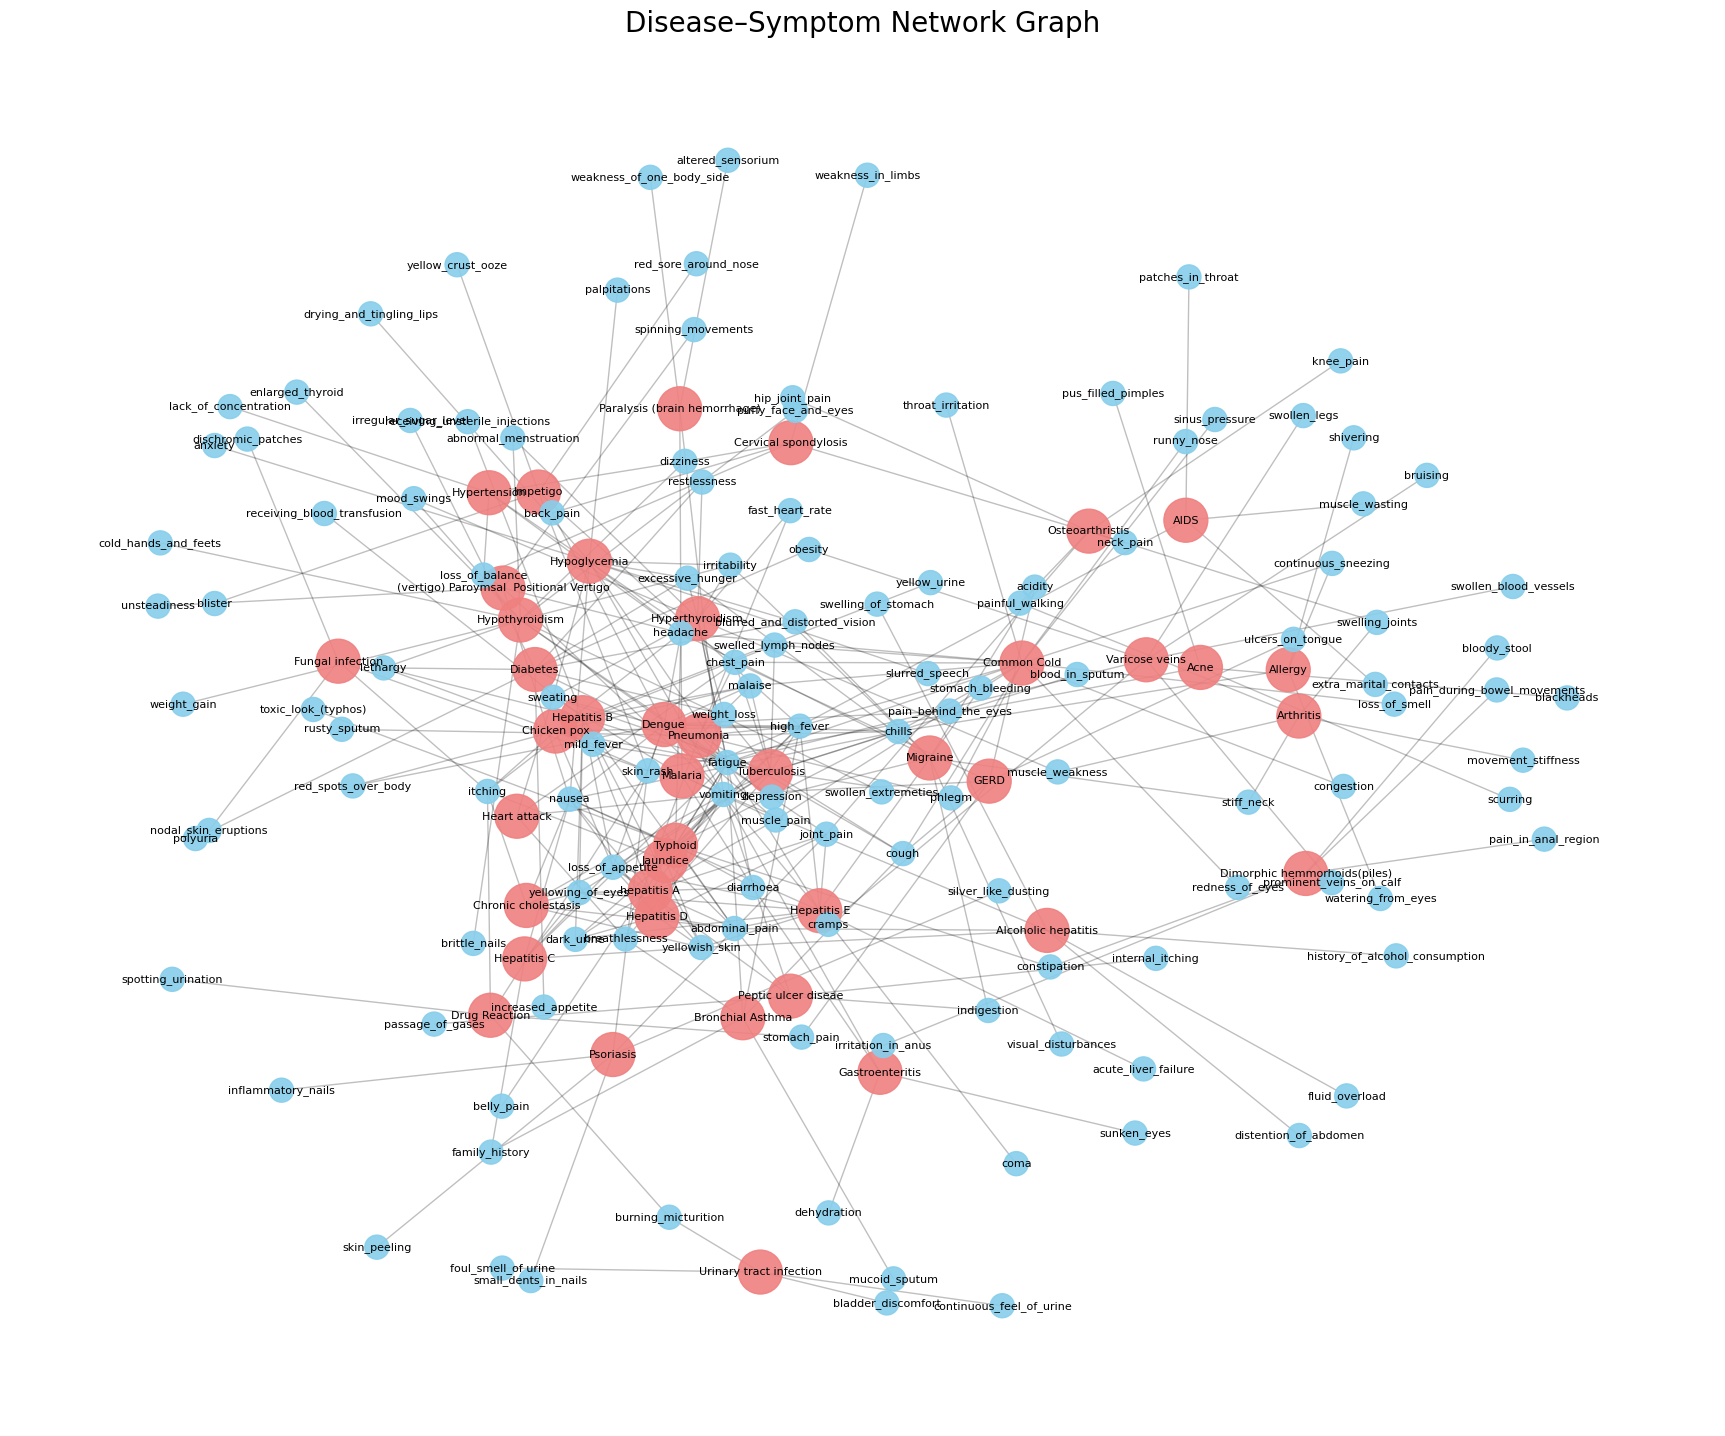

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add nodes
for disease in df_processed["Disease"].unique():
    G.add_node(disease, type="disease")

for symptom in all_symptoms:
    G.add_node(symptom, type="symptom")

# Add edges: disease ↔ symptom if symptom appears in that disease
for disease in df_processed["Disease"].unique():
    disease_df = df_processed[df_processed["Disease"] == disease]
    transactions = convert_to_transactions(disease_df)
    
    symptom_set = set().union(*transactions)
    
    for s in symptom_set:
        G.add_edge(disease, s)

plt.figure(figsize=(22, 18))

# Position layout for clarity
pos = nx.spring_layout(G, k=0.35, iterations=50)

# Color coding
colors = ["lightcoral" if G.nodes[node]["type"]=="disease" else "skyblue" 
          for node in G.nodes()]

# Sizes
sizes = [1000 if G.nodes[node]["type"]=="disease" else 300 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.25)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Disease–Symptom Network Graph", fontsize=20)
plt.axis("off")
plt.show()
